In [5]:
import time
import numpy as np
import pandas as pd
from math import sqrt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve
)
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('../data/processed/df_ready_model.csv')
df.head()

,time_n,accident,cluster_id,geometry,temperature_2m (°C),precipitation (mm),snowfall (cm),wind_speed_10m (km/h),Fiesta,dia_festivo,year,month,day,hour,day_of_week,is_weekend
0,2017-01-01 11:00:00,1,0,POINT (2.165199 41.385158),9.105882,0.0,0.0,13.5,0,0,2017,1,1,11,6,1
1,2017-01-02 19:00:00,1,53,POINT (2.179477 41.377111),7.305882,0.0,0.0,10.6,0,0,2017,1,2,19,0,0
2,2017-01-03 11:00:00,1,88,POINT (2.179893 41.378912),10.261765,0.0,0.0,5.9,0,0,2017,1,3,11,1,0
3,2017-01-04 10:00:00,1,70,POINT (2.170289 41.379488),10.561765,0.0,0.0,8.0,0,0,2017,1,4,10,2,0
4,2017-01-06 23:00:00,1,86,POINT (2.19509 41.387723),3.205882,0.0,0.0,7.7,0,1,2017,1,6,23,4,0


In [3]:
df.columns

Index(['time_n', 'accident', 'cluster_id', 'geometry', 'temperature_2m (°C)',
       'precipitation (mm)', 'snowfall (cm)', 'wind_speed_10m (km/h)',
       'Fiesta', 'dia_festivo', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3495160 entries, 0 to 3495159
Data columns (total 16 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   time_n                 object 
 1   accident               int64  
 2   cluster_id             int64  
 3   geometry               object 
 4   temperature_2m (°C)    float64
 5   precipitation (mm)     float64
 6   snowfall (cm)          float64
 7   wind_speed_10m (km/h)  float64
 8   Fiesta                 int64  
 9   dia_festivo            int64  
 10  year                   int64  
 11  month                  int64  
 12  day                    int64  
 13  hour                   int64  
 14  day_of_week            int64  
 15  is_weekend             int64  
dtypes: float64(4), int64(10), object(2)
memory usage: 426.7+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
accident,3495160.0,0.019291,0.137545,0.000000,0.000000,0.000000,0.000000,1.000000
cluster_id,3495160.0,49.453653,28.880266,-1.000000,24.000000,49.000000,74.000000,99.000000
temperature_2m (°C),3495160.0,15.418621,6.855878,-3.366667,9.961765,15.161765,20.961765,38.433333
precipitation (mm),3495160.0,0.078522,0.498225,0.000000,0.000000,0.000000,0.000000,27.600000
snowfall (cm),3495160.0,0.000096,0.007605,0.000000,0.000000,0.000000,0.000000,1.680000
wind_speed_10m (km/h),3495160.0,9.096537,5.453224,0.000000,5.400000,7.700000,11.600000,54.200000
Fiesta,3495160.0,0.205662,0.404185,0.000000,0.000000,0.000000,0.000000,1.000000
dia_festivo,3495160.0,0.049143,0.216167,0.000000,0.000000,0.000000,0.000000,1.000000
year,3495160.0,2020.604162,2.244124,2017.000000,2019.000000,2021.000000,2023.000000,2024.000000
month,3495160.0,6.478706,3.440125,1.000000,4.000000,6.000000,9.000000,12.000000


In [5]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

time_n                   0.0
accident                 0.0
cluster_id               0.0
geometry                 0.0
temperature_2m (°C)      0.0
precipitation (mm)       0.0
snowfall (cm)            0.0
wind_speed_10m (km/h)    0.0
Fiesta                   0.0
dia_festivo              0.0
year                     0.0
month                    0.0
day                      0.0
hour                     0.0
day_of_week              0.0
is_weekend               0.0
dtype: float64

In [8]:
df.head()

,time_n,accident,cluster_id,geometry,temperature_2m (°C),precipitation (mm),snowfall (cm),wind_speed_10m (km/h),Fiesta,dia_festivo,year,month,day,hour,day_of_week,is_weekend
0,2017-01-01 11:00:00,1,0,POINT (2.165199 41.385158),9.105882,0.0,0.0,13.5,0,0,2017,1,1,11,6,1
1,2017-01-02 19:00:00,1,53,POINT (2.179477 41.377111),7.305882,0.0,0.0,10.6,0,0,2017,1,2,19,0,0
2,2017-01-03 11:00:00,1,88,POINT (2.179893 41.378912),10.261765,0.0,0.0,5.9,0,0,2017,1,3,11,1,0
3,2017-01-04 10:00:00,1,70,POINT (2.170289 41.379488),10.561765,0.0,0.0,8.0,0,0,2017,1,4,10,2,0
4,2017-01-06 23:00:00,1,86,POINT (2.19509 41.387723),3.205882,0.0,0.0,7.7,0,1,2017,1,6,23,4,0


In [3]:
# Asegurar formato datetime
df["time_n"] = pd.to_datetime(df["time_n"], errors="coerce")

# Definir ventanas
train_start = pd.Timestamp("2017-01-01 00:00:00")
train_end   = pd.Timestamp("2023-12-31 23:00:00")
test_start  = pd.Timestamp("2024-01-01 00:00:00")
test_end    = pd.Timestamp("2024-12-31 23:00:00") 

# Split
df_train = df[(df["time_n"] >= train_start) & (df["time_n"] <= train_end)].copy()
df_test  = df[(df["time_n"] >= test_start)  & (df["time_n"] <= test_end)].copy()

print("Tamaño train:", df_train.shape)
print("Tamaño test :", df_test.shape)

print("Rango train:", df_train["time_n"].min(), "→", df_train["time_n"].max())
print("Rango test :", df_test["time_n"].min(), "→", df_test["time_n"].max())

# Verificación: nº de horas en test (enero tiene 31*24 = 744 horas)
n_horas_test = df_test["time_n"].nunique()
print("Horas únicas en test:", n_horas_test)

Tamaño train: (3047548, 16)
Tamaño test : (447612, 16)
Rango train: 2017-01-01 00:00:00 → 2023-12-31 23:00:00
Rango test : 2024-01-01 00:00:00 → 2024-12-31 23:00:00
Horas únicas en test: 8784


In [11]:
df_test.describe().T

,count,mean,min,25%,50%,75%,max,std
time_n,46258,2021-01-16 03:09:48.118811904,2021-01-01 00:00:00,2021-01-08 01:00:00,2021-01-16 03:00:00,2021-01-24 01:00:00,2021-01-31 23:00:00,NaN
accident,46258.0,0.010593,0.0,0.0,0.0,0.0,1.0,0.102376
cluster_id,46258.0,49.411604,-1.0,24.0,49.0,74.0,99.0,28.884279
temperature_2m (°C),46258.0,6.585261,-3.366667,3.658824,6.105882,9.316667,21.32807,4.090531
precipitation (mm),46258.0,0.046498,0.0,0.0,0.0,0.0,2.2,0.199118
snowfall (cm),46258.0,0.000799,0.0,0.0,0.0,0.0,0.49,0.015356
wind_speed_10m (km/h),46258.0,11.466235,0.0,7.0,9.9,14.7,42.3,6.396626
Fiesta,46258.0,0.035626,0.0,0.0,0.0,0.0,1.0,0.185359
dia_festivo,46258.0,0.085023,0.0,0.0,0.0,0.0,1.0,0.278919
year,46258.0,2021.0,2021.0,2021.0,2021.0,2021.0,2021.0,0.0


In [4]:
# Features y target
features = [c for c in df.columns if c not in ["time_n","geometry","accident"]]

X_train, y_train = df_train[features], df_train["accident"]
X_test, y_test   = df_test[features],  df_test["accident"]

print("Features usadas:", features)

Features usadas: ['cluster_id', 'temperature_2m (°C)', 'precipitation (mm)', 'snowfall (cm)', 'wind_speed_10m (km/h)', 'Fiesta', 'dia_festivo', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend']


In [13]:
X_train.head()

,cluster_id,temperature_2m (°C),precipitation (mm),snowfall (cm),wind_speed_10m (km/h),Fiesta,dia_festivo,year,month,day,hour,day_of_week,is_weekend
0,0,9.105882,0.0,0.0,13.5,0,0,2017,1,1,11,6,1
1,53,7.305882,0.0,0.0,10.6,0,0,2017,1,2,19,0,0
2,88,10.261765,0.0,0.0,5.9,0,0,2017,1,3,11,1,0
3,70,10.561765,0.0,0.0,8.0,0,0,2017,1,4,10,2,0
4,86,3.205882,0.0,0.0,7.7,0,1,2017,1,6,23,4,0


In [5]:
# Dataset de LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# ⚠️ Modelo baseline (sin hiperparámetros extra)
params = {
    "objective": "binary",
    "metric": ["auc"],   # solo AUC para empezar
    "verbosity": -1
}

# Entrenar
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=["train","valid"],
    num_boost_round=100,      # baseline con pocas iteraciones
)

# Predicciones
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)



In [6]:
# Métricas básicas
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("PR AUC (Average Precision):", average_precision_score(y_test, y_pred_proba))


Confusion matrix:
 [[439805    271]
 [  7501     35]]

Classification report:
               precision    recall  f1-score   support

           0     0.9832    0.9994    0.9912    440076
           1     0.1144    0.0046    0.0089      7536

    accuracy                         0.9826    447612
   macro avg     0.5488    0.5020    0.5001    447612
weighted avg     0.9686    0.9826    0.9747    447612

ROC AUC: 0.7992090151290505
PR AUC (Average Precision): 0.056409544949361574


In [7]:
# Calcular pesos
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 49.8874565856265


In [8]:
n_pos,n_neg

(np.int64(59888), np.int64(2987660))

In [ ]:
params_bal = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "verbosity": -1,
    "scale_pos_weight": scale_pos_weight,
}

# Entrenar con callbacks
model_bal = lgb.train(
    params_bal,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=["train","valid"],
    num_boost_round=200,
    callbacks=[early_stopping(stopping_rounds=30), log_evaluation(50)]
)

# Predicciones
proba_bal = model_bal.predict(X_test, num_iteration=model_bal.best_iteration)
y_pred_bal = (proba_bal >= 0.5).astype(int)

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("\nClassification report:\n", classification_report(y_test, y_pred_bal, digits=4))
print("ROC AUC:", roc_auc_score(y_test, proba_bal))
print("PR AUC:", average_precision_score(y_test, proba_bal))

Training until validation scores don't improve for 30 rounds
[50]	train's auc: 0.845096	train's average_precision: 0.110139	valid's auc: 0.80601	valid's average_precision: 0.065262
[100]	train's auc: 0.851597	train's average_precision: 0.117565	valid's auc: 0.807185	valid's average_precision: 0.0661202
[150]	train's auc: 0.85668	train's average_precision: 0.122628	valid's auc: 0.807569	valid's average_precision: 0.067973
Early stopping, best iteration is:
[135]	train's auc: 0.855448	train's average_precision: 0.121344	valid's auc: 0.807719	valid's average_precision: 0.0674025

Confusion matrix:
 [[326648 113428]
 [  1966   5570]]

Classification report:
               precision    recall  f1-score   support

           0     0.9940    0.7423    0.8499    440076
           1     0.0468    0.7391    0.0880      7536

    accuracy                         0.7422    447612
   macro avg     0.5204    0.7407    0.4690    447612
weighted avg     0.9781    0.7422    0.8371    447612

ROC AUC: 0

: 

In [10]:
# ratio para spw
n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
ratio = n_neg / max(1, n_pos)
spw_candidates = sorted(set([
    1.0,
    round(sqrt(ratio), 2),      # suavizado (≈ 7–8 en tu caso)
    round(ratio/3, 2),
    round(ratio/2, 2),
    round(ratio, 2)             # balance fuerte (≈ 50–60 en tu caso)
]))
print("scale_pos_weight candidates:", spw_candidates)

# -----------------------------

scale_pos_weight candidates: [1.0, 7.06, 16.63, 24.94, 49.89]



>>> Máximo F1 (umbral=0.6334)
Confusion matrix:
 [[409860  30216]
 [  5110   2426]]
              precision    recall  f1-score   support

           0     0.9877    0.9313    0.9587    440076
           1     0.0743    0.3219    0.1208      7536

    accuracy                         0.9211    447612
   macro avg     0.5310    0.6266    0.5397    447612
weighted avg     0.9723    0.9211    0.9446    447612


>>> Precisión mínima 0.10 (umbral=0.7403)
Confusion matrix:
 [[436116   3960]
 [  7096    440]]
              precision    recall  f1-score   support

           0     0.9840    0.9910    0.9875    440076
           1     0.1000    0.0584    0.0737      7536

    accuracy                         0.9753    447612
   macro avg     0.5420    0.5247    0.5306    447612
weighted avg     0.9691    0.9753    0.9721    447612


PR AUC global: 0.06838146648486751


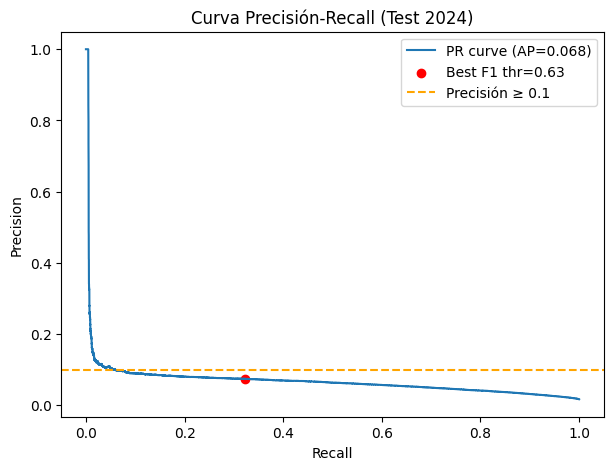

In [16]:
# Probabilidades del modelo 2 (ya las tienes en proba_bal)
# proba_bal = model_bal.predict(X_test, num_iteration=model_bal.best_iteration)

# 1) Curva precisión-recall
precision, recall, thresholds = precision_recall_curve(y_test, proba_bal)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-12)

# 2) Umbral con mejor F1
j_best = np.argmax(f1_scores)
thr_f1 = thresholds[j_best]
best_f1 = f1_scores[j_best]

# 3) Umbral con precisión mínima (ej. 0.10)
prec_min = 0.10
ok = np.where(precision[:-1] >= prec_min)[0]
if len(ok) > 0:
    j_pmin = ok[np.argmax(recall[ok])]
    thr_pmin = thresholds[j_pmin]
else:
    thr_pmin = thr_f1  # fallback

# 4) Evaluación en test con ambos umbrales
def eval_threshold(thr, name=""):
    y_pred_thr = (proba_bal >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_thr)
    print(f"\n>>> {name} (umbral={thr:.4f})")
    print("Confusion matrix:\n", cm)
    print(classification_report(y_test, y_pred_thr, digits=4))

eval_threshold(thr_f1, "Máximo F1")
eval_threshold(thr_pmin, "Precisión mínima 0.10")

# 5) Métrica global PR AUC
print("\nPR AUC global:", average_precision_score(y_test, proba_bal))

# 6) Curva precisión-recall
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"PR curve (AP={average_precision_score(y_test, proba_bal):.3f})")
plt.scatter(recall[j_best], precision[j_best], c='red', label=f"Best F1 thr={thr_f1:.2f}")
plt.axhline(prec_min, color='orange', linestyle='--', label=f"Precisión ≥ {prec_min}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precisión-Recall (Test 2024)")
plt.legend()
plt.show()